In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import pingouin as pg 

In [19]:
rawdata = pd.read_csv(r'C:\Users\georg\Desktop\Bstorm Visual studio code\01 - Python_Full_Course\07_Machine_learning\Exercice ML-DM\3. stroke\data\stroke.csv',index_col='id')
rawdata.sort_values(by='id')

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,,,,,,,,,,,
67,Female,17.0,0,0,No,Private,Urban,92.97,NaN,formerly smoked,0
77,Female,13.0,0,0,No,children,Rural,85.81,18.6,Unknown,0
84,Male,55.0,0,0,Yes,Private,Urban,89.17,31.5,never smoked,0
91,Female,42.0,0,0,No,Private,Urban,98.53,18.5,never smoked,0
99,Female,31.0,0,0,No,Private,Urban,108.89,52.3,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...
72911,Female,57.0,1,0,Yes,Private,Rural,129.54,60.9,smokes,0
72914,Female,19.0,0,0,No,Private,Urban,90.57,24.2,Unknown,0
72915,Female,45.0,0,0,Yes,Private,Urban,172.33,45.3,formerly smoked,0


In [26]:
for col in rawdata.columns:
    display(rawdata[col].value_counts())

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

age
78.00    102
57.00     95
52.00     90
54.00     87
51.00     86
        ... 
1.40       3
0.48       3
0.16       3
0.08       2
0.40       2
Name: count, Length: 104, dtype: int64

hypertension
0    4612
1     498
Name: count, dtype: int64

heart_disease
0    4834
1     276
Name: count, dtype: int64

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

...

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

avg_glucose_level
93.88     6
73.00     5
72.49     5
91.85     5
91.68     5
         ..
61.98     1
91.01     1
120.03    1
138.51    1
118.41    1
Name: count, Length: 3979, dtype: int64

bmi
28.7    41
28.4    38
27.7    37
27.6    37
26.7    37
        ..
47.9     1
13.0     1
13.9     1
54.1     1
14.9     1
Name: count, Length: 418, dtype: int64

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

stroke
0    4861
1     249
Name: count, dtype: int64

In [68]:
FIGSIZE = (5,3)

In [20]:
rawdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5110 entries, 9046 to 44679
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 479.1+ KB


In [13]:
rawdata.isna()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,False,False,False,False,False,False,False,False,False,True,False,False
5106,False,False,False,False,False,False,False,False,False,False,False,False
5107,False,False,False,False,False,False,False,False,False,False,False,False
5108,False,False,False,False,False,False,False,False,False,False,False,False


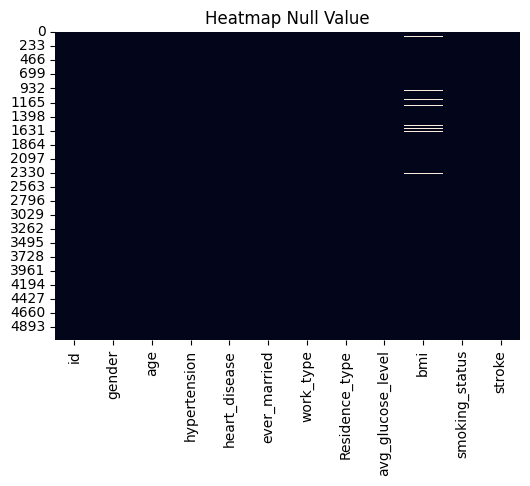

In [12]:
plt.figure(figsize=FIGSIZE)
plt.title('Heatmap Null Value')
sns.heatmap(rawdata.isna(),cbar=False)
plt.show()


In [31]:
cont_feature = rawdata.select_dtypes(float)
cat_feature = rawdata.select_dtypes(exclude=float)
cat_feature 

,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,stroke
id,,,,,,,,
9046,Male,0,1,Yes,Private,Urban,formerly smoked,1
51676,Female,0,0,Yes,Self-employed,Rural,never smoked,1
31112,Male,0,1,Yes,Private,Rural,never smoked,1
60182,Female,0,0,Yes,Private,Urban,smokes,1
1665,Female,1,0,Yes,Self-employed,Rural,never smoked,1
...,...,...,...,...,...,...,...,...
18234,Female,1,0,Yes,Private,Urban,never smoked,0
44873,Female,0,0,Yes,Self-employed,Urban,never smoked,0
19723,Female,0,0,Yes,Self-employed,Rural,never smoked,0


### Analyse Univariée

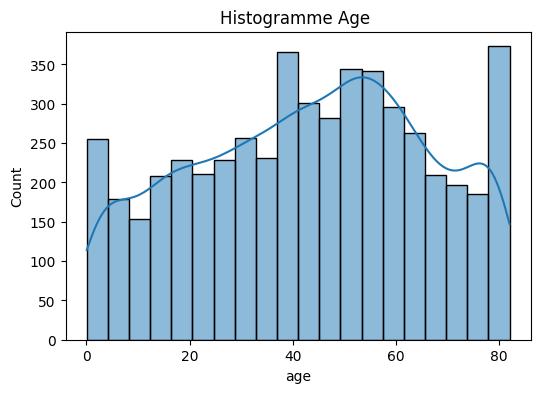

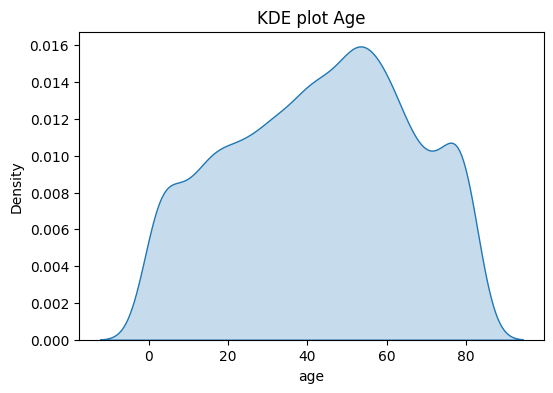

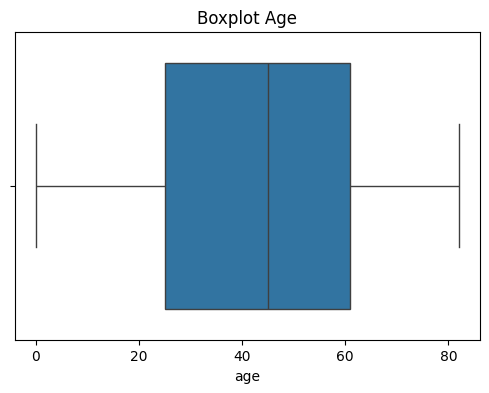

age
78.00    102
57.00     95
52.00     90
54.00     87
51.00     86
        ... 
1.40       3
0.48       3
0.16       3
0.08       2
0.40       2
Name: count, Length: 104, dtype: int64

In [ ]:
plt.figure(figsize=FIGSIZE)
plt.title('Histogramme Age ')
sns.histplot(data=rawdata,x='age',kde=True)
plt.show()

plt.figure(figsize=FIGSIZE)
plt.title('KDE plot Age')
sns.kdeplot(data=rawdata,x='age',fill=True)
plt.show()

plt.figure(figsize=FIGSIZE)
plt.title('Boxplot Age')
sns.boxplot(data=rawdata,x='age')
plt.show()



count    5110.000000
mean       43.226614
std        22.612647
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

count    5110.000000
mean      106.147677
std        45.283560
min        55.120000
25%        77.245000
50%        91.885000
75%       114.090000
max       271.740000
Name: avg_glucose_level, dtype: float64

count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

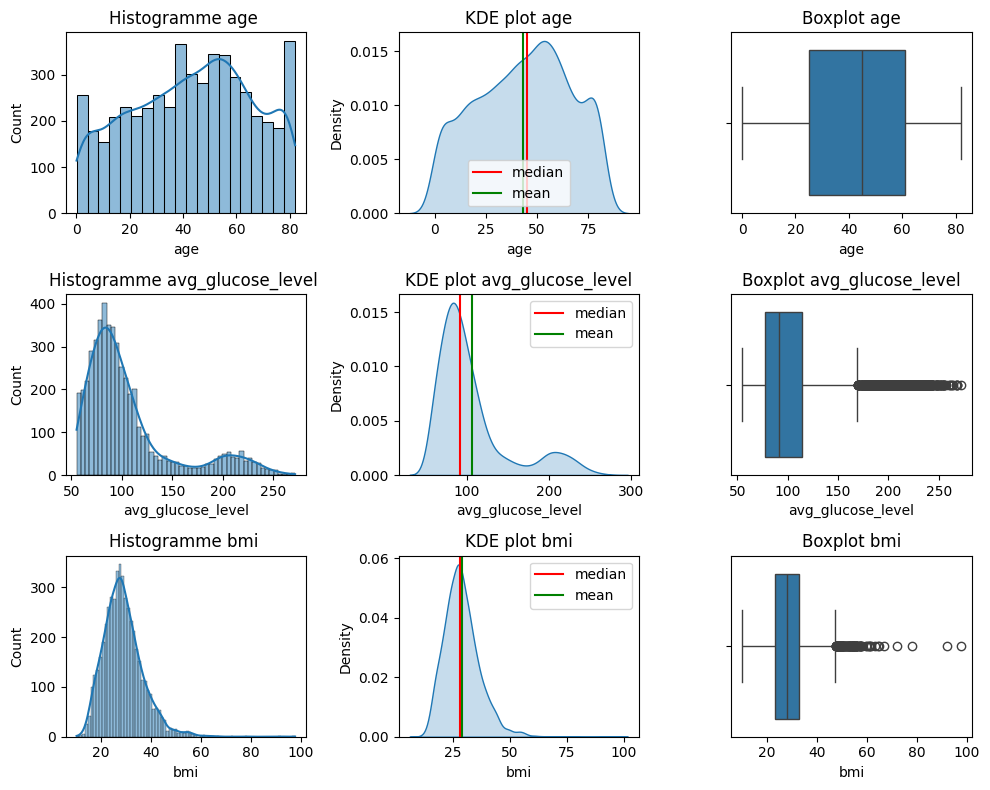

In [ ]:
plt.figure(figsize=(10,8))
for i,col in enumerate(cont_feature.columns):
    plt.subplot(3,3,(3*i)+1)
    plt.title(f'Histogramme {col} ')
    sns.histplot(data=rawdata,x=col,kde=True)
    plt.subplot(3,3,(3*i)+2)
    plt.title(f'KDE plot {col}')
    sns.kdeplot(data=rawdata,x=col,fill=True)
    plt.axvline(rawdata[col].median(),c="r",label='median')
    plt.axvline(rawdata[col].mean(),c='g',label='mean')
    plt.legend()
    plt.subplot(3,3,(3*i)+3)
    plt.title(f'Boxplot {col}')
    sns.boxplot(data=rawdata,x=col)
    plt.tight_layout()
    display(rawdata[col].describe())
plt.show()

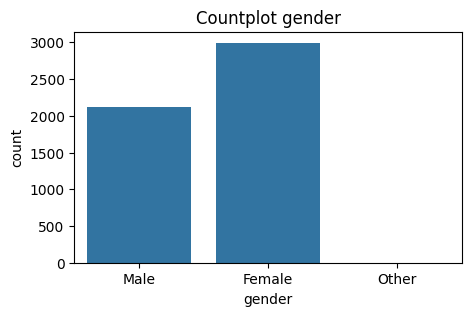

gender
Female    0.585910
Male      0.413894
Other     0.000196
Name: proportion, dtype: float64

In [ ]:
plt.figure(figsize=FIGSIZE)
plt.title('Countplot gender')
sns.countplot(data=rawdata,x='gender')
plt.show()

rawdata['gender'].value_counts(normalize=True)

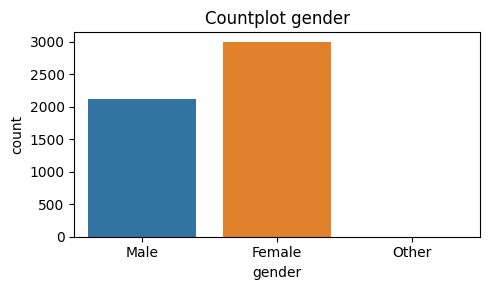

gender
Female    0.585910
Male      0.413894
Other     0.000196
Name: proportion, dtype: float64

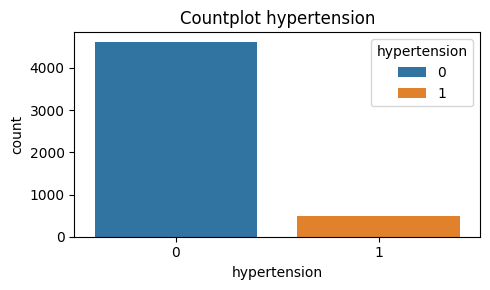

hypertension
0    0.902544
1    0.097456
Name: proportion, dtype: float64

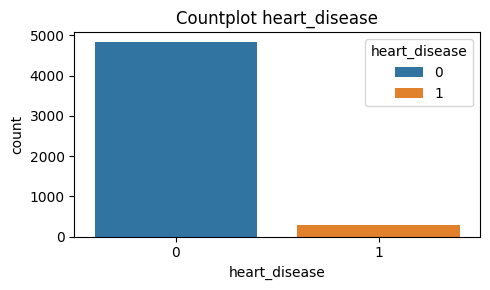

heart_disease
0    0.945988
1    0.054012
Name: proportion, dtype: float64

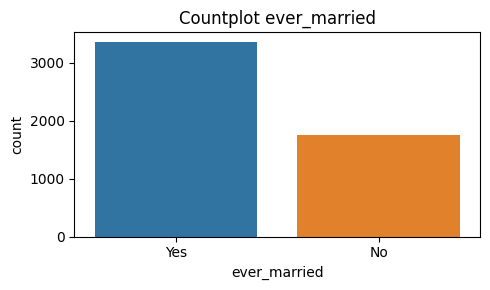

ever_married
Yes    0.656164
No     0.343836
Name: proportion, dtype: float64

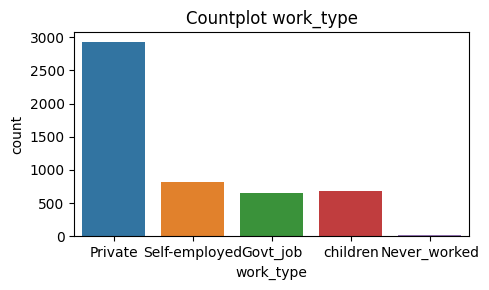

work_type
Private          0.572407
Self-employed    0.160274
children         0.134442
Govt_job         0.128571
Never_worked     0.004305
Name: proportion, dtype: float64

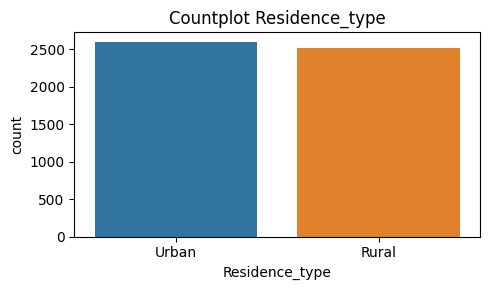

Residence_type
Urban    0.508023
Rural    0.491977
Name: proportion, dtype: float64

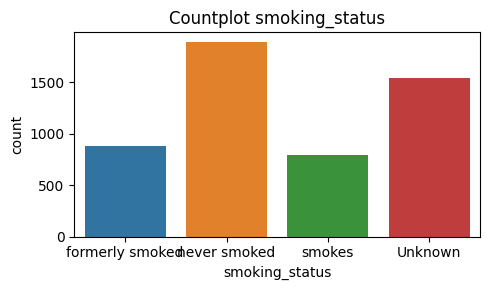

smoking_status
never smoked       0.370254
Unknown            0.302153
formerly smoked    0.173190
smokes             0.154403
Name: proportion, dtype: float64

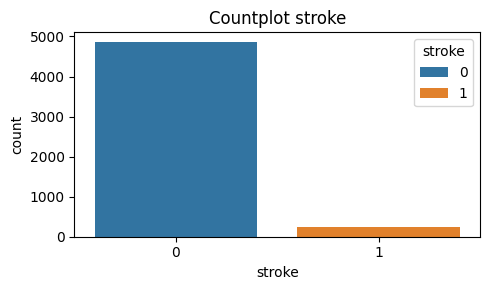

stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64

In [85]:
for col in cat_feature.columns:
    plt.figure(figsize=FIGSIZE)
    plt.title(f'Countplot {col}')
    sns.countplot(data=rawdata,x=col,hue=col)
    plt.tight_layout()
    plt.show()
    display(rawdata[col].value_counts(normalize=True))

### Analyse Bivariée

In [109]:
crossgenre = pd.crosstab(rawdata['gender'],rawdata['stroke'],normalize='columns').drop(index='Other')

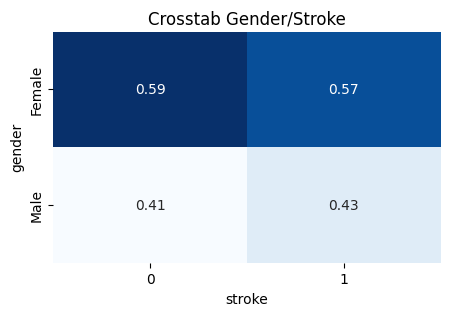

stroke,0,1
gender,,
Female,0.586916,0.566265
Male,0.412878,0.433735


In [111]:
plt.figure(figsize=FIGSIZE)
plt.title('Crosstab Gender/Stroke')
sns.heatmap(crossgenre,cbar=False,annot=True,cmap='Blues')
plt.show()
crossgenre


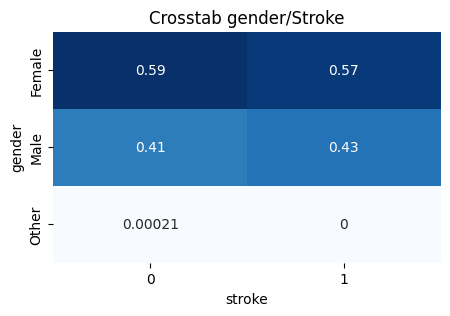

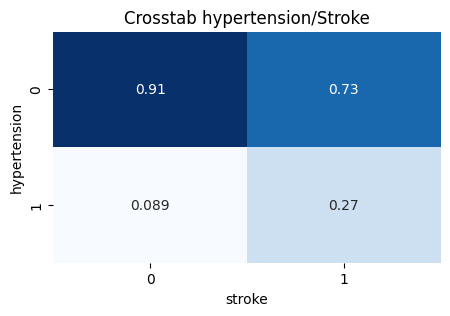

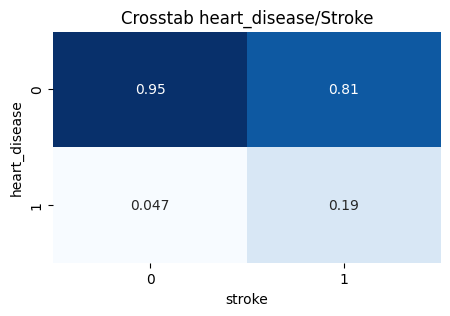

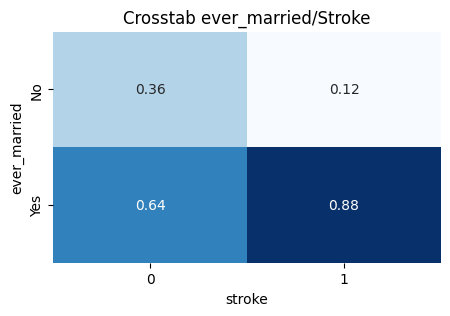

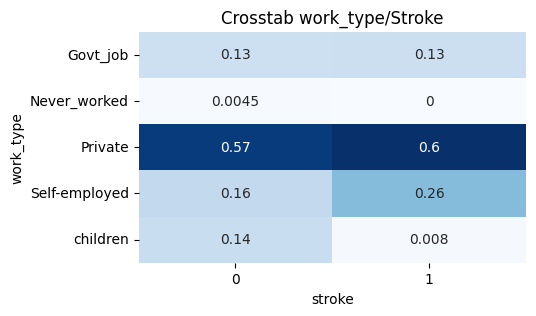

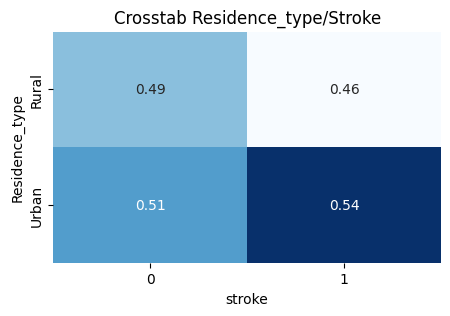

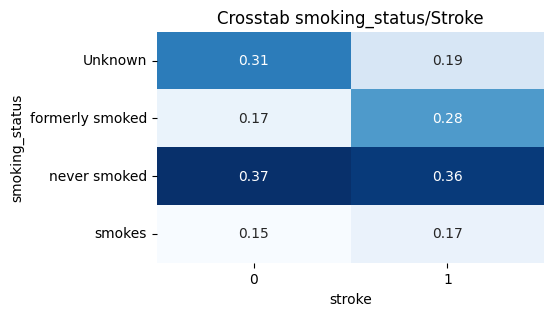

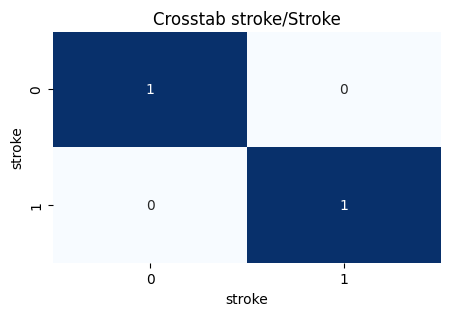

In [112]:
for col in cat_feature.columns:
    plt.figure(figsize=FIGSIZE)
    plt.title(f'Crosstab {col}/Stroke')
    sns.heatmap(pd.crosstab(rawdata[col],rawdata['stroke'],normalize='columns'),cbar=False,annot=True,cmap='Blues')
    plt.show()


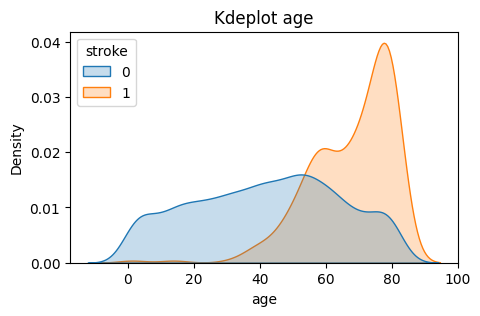

In [119]:
plt.figure(figsize=FIGSIZE)
plt.title('Kdeplot age')
sns.kdeplot(data=rawdata,x='age',fill=True,hue='stroke',common_norm=False)
plt.show()

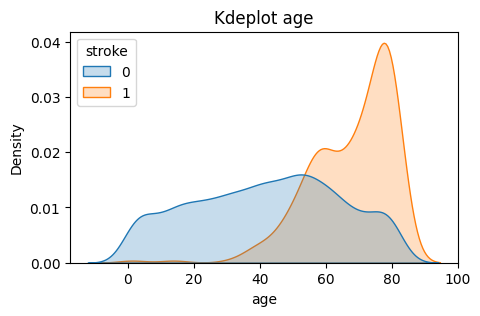

age                                                    
         count       mean        std   min   25%   50%   75%   max
stroke                                                            
0       4861.0  41.971545  22.291940  0.08  24.0  43.0  59.0  82.0
1        249.0  67.728193  12.727419  1.32  59.0  71.0  78.0  82.0

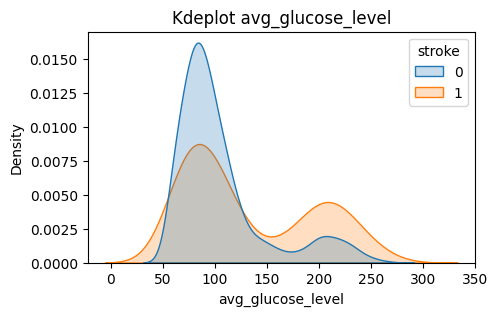

avg_glucose_level                                                       \
                   count        mean        std    min    25%     50%     75%   
stroke                                                                          
0                 4861.0  104.795513  43.846069  55.12  77.12   91.47  112.83   
1                  249.0  132.544739  61.921056  56.11  79.79  105.22  196.71   

                
           max  
stroke          
0       267.76  
1       271.74

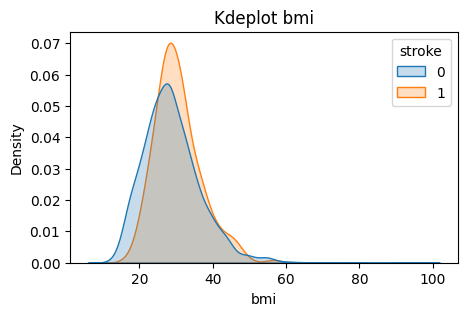

bmi                                                   
         count       mean       std   min   25%   50%   75%   max
stroke                                                           
0       4700.0  28.823064  7.908287  10.3  23.4  28.0  33.1  97.6
1        209.0  30.471292  6.329452  16.9  26.4  29.7  33.7  56.6

In [123]:
for col in cont_feature.columns:
    plt.figure(figsize=FIGSIZE)
    plt.title(f'Kdeplot {col}')
    sns.kdeplot(data=rawdata,x=col,fill=True,hue='stroke',common_norm=False)
    plt.show()
    display(rawdata[[col,'stroke']].groupby('stroke').describe())

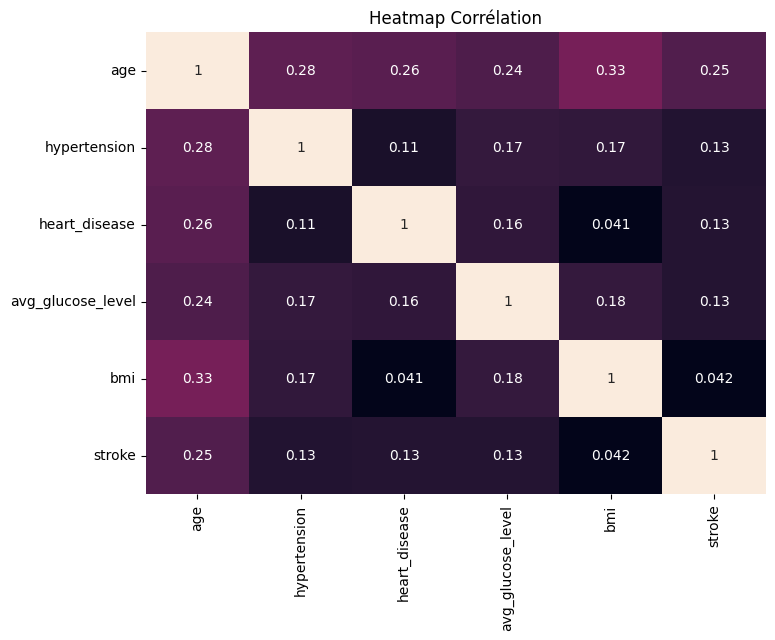

In [126]:
plt.figure(figsize=(8,6))
plt.title('Heatmap Corrélation')
sns.heatmap(rawdata.corr(numeric_only=True),cbar=False,annot=True)
plt.show()

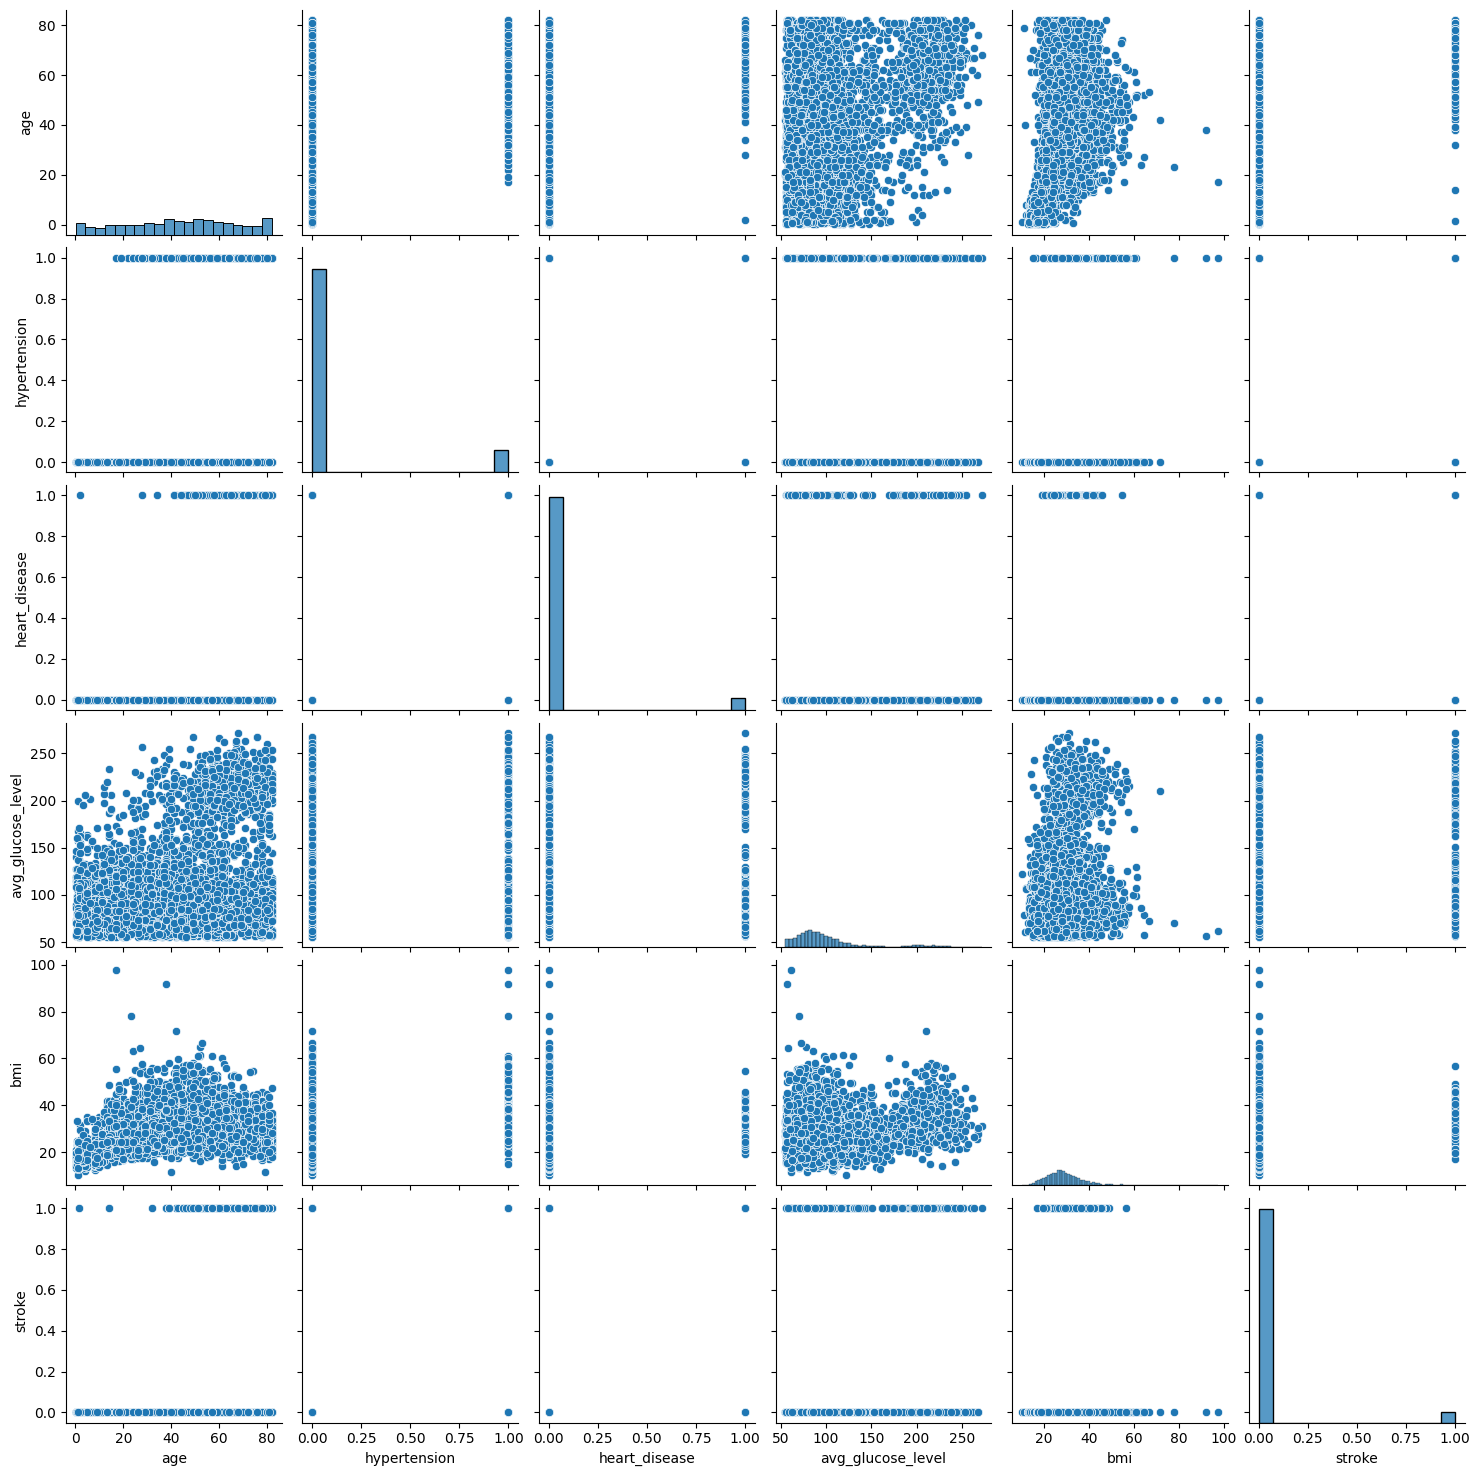

In [128]:
sns.pairplot(rawdata)
plt.show()